In [40]:
import pandas as pd
from matplotlib import pyplot as plt
from scipy import stats

from src.app.utils.db_manager import DatabaseManager

pd.set_option("display.max_columns", None)

# Загрузка данных из БД

In [41]:
db_manager = DatabaseManager()
application_table_name = "application"
query = f"""
SELECT 
    *
FROM {application_table_name}
"""
df = db_manager.get_df_from_query(query)

c:\Users\Сергей\Desktop\vs code\shift\credit_scoring\src\app\utils\db_manager.py:83: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, self._connection)


Время выполнения: 0:00:16


target - вероятность дефолта клиента

In [42]:
df.head()

,sk_id_curr,target,name_contract_type,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,amt_goods_price,name_type_suite,name_income_type,name_education_type,name_family_status,name_housing_type,region_population_relative,days_birth,days_employed,days_registration,days_id_publish,own_car_age,flag_mobil,flag_emp_phone,flag_work_phone,flag_cont_mobile,flag_phone,flag_email,occupation_type,cnt_fam_members,region_rating_client,region_rating_client_w_city,weekday_appr_process_start,hour_appr_process_start,reg_region_not_live_region,reg_region_not_work_region,live_region_not_work_region,reg_city_not_live_city,reg_city_not_work_city,live_city_not_work_city,organization_type,ext_source_1,ext_source_2,ext_source_3,apartments_avg,basementarea_avg,years_beginexpluatation_avg,years_build_avg,commonarea_avg,elevators_avg,entrances_avg,floorsmax_avg,floorsmin_avg,landarea_avg,livingapartments_avg,livingarea_avg,nonlivingapartments_avg,nonlivingarea_avg,apartments_mode,basementarea_mode,years_beginexpluatation_mode,years_build_mode,commonarea_mode,elevators_mode,entrances_mode,floorsmax_mode,floorsmin_mode,landarea_mode,livingapartments_mode,livingarea_mode,nonlivingapartments_mode,nonlivingarea_mode,apartments_medi,basementarea_medi,years_beginexpluatation_medi,years_build_medi,commonarea_medi,elevators_medi,entrances_medi,floorsmax_medi,floorsmin_medi,landarea_medi,livingapartments_medi,livingarea_medi,nonlivingapartments_medi,nonlivingarea_medi,fondkapremont_mode,housetype_mode,totalarea_mode,wallsmaterial_mode,emergencystate_mode,obs_30_cnt_social_circle,def_30_cnt_social_circle,obs_60_cnt_social_circle,def_60_cnt_social_circle,days_last_phone_change,flag_document_2,flag_document_3,flag_document_4,flag_document_5,flag_document_6,flag_document_7,flag_document_8,flag_document_9,flag_document_10,flag_document_11,flag_document_12,flag_document_13,flag_document_14,flag_document_15,flag_document_16,flag_document_17,flag_document_18,flag_document_19,flag_document_20,flag_document_21,amt_req_credit_bureau_hour,amt_req_credit_bureau_day,amt_req_credit_bureau_week,amt_req_credit_bureau_mon,amt_req_credit_bureau_qrt,amt_req_credit_bureau_year
0,100002,1.0,Cash loans,M,N,Y,0.0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2.0,2.0,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0.0,Cash loans,F,N,N,0.0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1.0,1.0,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0.0,Revolving loans,M,Y,Y,0.0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2.0,2.0,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

## Гипотеза 1

Нулевая гипотеза (H0): Отношение кредита к доходу не влияет на дефолт клиента

Альтернатива (H1): Отношение кредита к доходу влияет на дефолт клиента (чем выше, тем больше шанс дефолта)

In [43]:
def describe_group(data, name, target_value=None):
    """
    Выводит описательную статистику для группы
    """
    if target_value is not None:
        print(f"{name} (target={target_value}):")
    else:
        print(f"{name}:")

    print(f"n = {len(data):,}")
    print(f"Среднее = {data.mean():,.3f}")
    print(f"Медиана = {data.median():,.3f}")
    print(f"Std = {data.std():,.3f}")
    print(f"Min = {data.min():,.3f}")
    print(f"Max = {data.max():,.3f}")
    print(f"25-й перцентиль = {data.quantile(0.25):,.3f}")
    print(f"75-й перцентиль = {data.quantile(0.75):,.3f}")

In [44]:
df["credit_to_income"] = df["amt_credit"] / df["amt_income_total"]

credit_to_income_target_1 = df[df["target"] == 1]["credit_to_income"]

credit_to_income_target_0 = df[df["target"] == 0]["credit_to_income"]

describe_group(credit_to_income_target_1, "Группа с target=1", target_value=1)
describe_group(credit_to_income_target_0, "Группа с target=0", target_value=0)

Группа с target=1 (target=1):
n = 24,825
Среднее = 3.887
Медиана = 3.253
Std = 2.627
Min = 0.005
Max = 84.737
25-й перцентиль = 2.130
75-й перцентиль = 4.992
Группа с target=0 (target=0):
n = 282,686
Среднее = 3.964
Медиана = 3.267
Std = 2.695
Min = 0.037
Max = 49.227
25-й перцентиль = 2.000
75-й перцентиль = 5.191


C:\Users\Сергей\AppData\Local\Temp\ipykernel_9688\3561683120.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=["target=0", "target=1"])


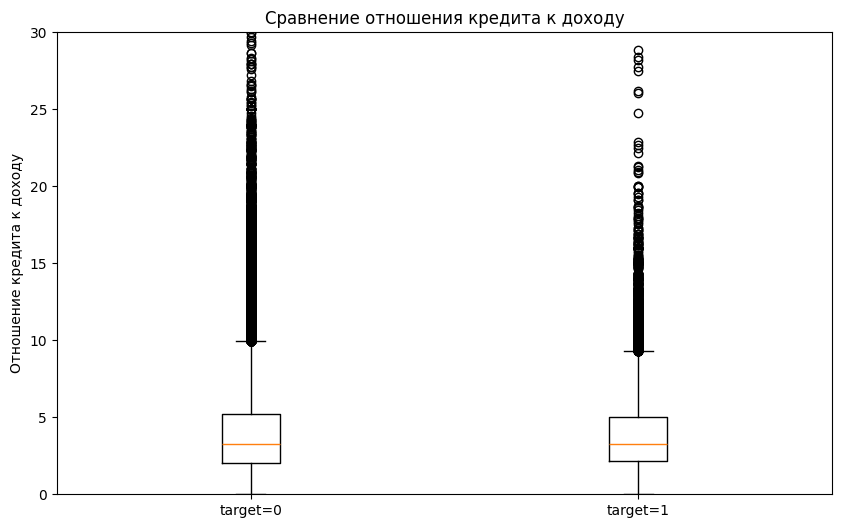

In [45]:
plt.figure(figsize=(10, 6))
data_to_plot = [credit_to_income_target_0, credit_to_income_target_1]
plt.boxplot(data_to_plot, labels=["target=0", "target=1"])
plt.title("Сравнение отношения кредита к доходу")
plt.ylabel("Отношение кредита к доходу")
plt.ylim(0, 30)
plt.show()

По описательным статистикам не видно явных различий между группами. Медианы и средние почти совпадают. Основное различие - в группе с target=1 есть экстремальные выбросы, которые могут искажать среднее.

Требуется статистический тест для окончательного вывода, так как визуально различий нет, но большой размер выборки может выявить статистически значимую разницу.

Проверка на нормальность распределения, с помощью теста и QQ-Plot

In [46]:
def show_qq_plot(sample1, sample2, name1="Группа 1", name2="Группа 2"):
    # QQ-plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    stats.probplot(sample1, plot=axes[0])
    axes[0].set_title(f"QQ-plot: {name1} (n={len(sample1)})")
    axes[0].grid(True)

    stats.probplot(sample2, plot=axes[1])
    axes[1].set_title(f"QQ-plot: {name2} (n={len(sample2)})")
    axes[1].grid(True)
    plt.tight_layout()
    plt.show()

In [47]:
def check_normality_with_qq(
    data1, data2, name1="Группа 1", name2="Группа 2", sample_size=5000, alpha=0.005
):
    """
    Проверяет нормальность двух выборок с помощью теста Шапиро-Уилка и QQ-plot
    """
    sample1 = data1.sample(min(sample_size, len(data1)))
    sample2 = data2.sample(min(sample_size, len(data2)))

    # Тест Шапиро-Уилка
    _, p1 = stats.shapiro(sample1)
    _, p2 = stats.shapiro(sample2)

    print(f"{name1}: p-value = {p1:.10f}")
    print(f"{name2}: p-value = {p2:.10f}")

    show_qq_plot(sample1, sample2, name1, name2)

    if p1 < alpha or p2 < alpha:
        print("Распределение не нормальное (p-value < alpha)")
        if p1 < alpha:
            print(f"p-value ({p1:.10f}) < alpha ({alpha})")
        else:
            print(f"p-value ({p2:.10f}) < alpha ({alpha})")
        print("Используем непараметрический критерий (Mann-Whitney U)")
        return False
    else:
        print("Распределение нормальное")
        print("Используем параметрический критерий (t-тест)")
        return True

Функция для сравнения двух групп

In [48]:
def compare_two_groups(data1, data2, name1="Группа 1", name2="Группа 2", alpha=0.005):
    """
    Сравнивает две группы с помощью t-теста или U-теста
    """
    # Проверка нормальности
    use_parametric = check_normality_with_qq(data1, data2, name1, name2)

    if use_parametric:
        stat, p_value = stats.ttest_ind(data1, data2)
        print("t-тест:")
        print(f"t-statistic = {stat:.4f}")
        print(f"p-value = {p_value:.10f}")
    else:
        stat, p_value = stats.mannwhitneyu(data1, data2)
        print("U-тест Манна-Уитни:")
        print(f"U-statistic = {stat:.2f}")
        print(f"p-value = {p_value:.10f}")

    print(f"Фиксированный уровень значимости alpha = {alpha}")

    if p_value < alpha:
        print(f"p-value ({p_value:.10f}) < alpha ({alpha})")
        print("Отвергаем нулевую гипотезу H0")
        print(f"{name1} и {name2} статистически значимо различаются")
    else:
        print(f"p-value ({p_value:.10f}) >= alpha ({alpha})")
        print("Не отвергаем нулевую гипотезу H0")
        print(f"Нет статистически значимых различий между {name1} и {name2}")

    return p_value

target=0: p-value = 0.0000000000
target=1: p-value = 0.0000000000


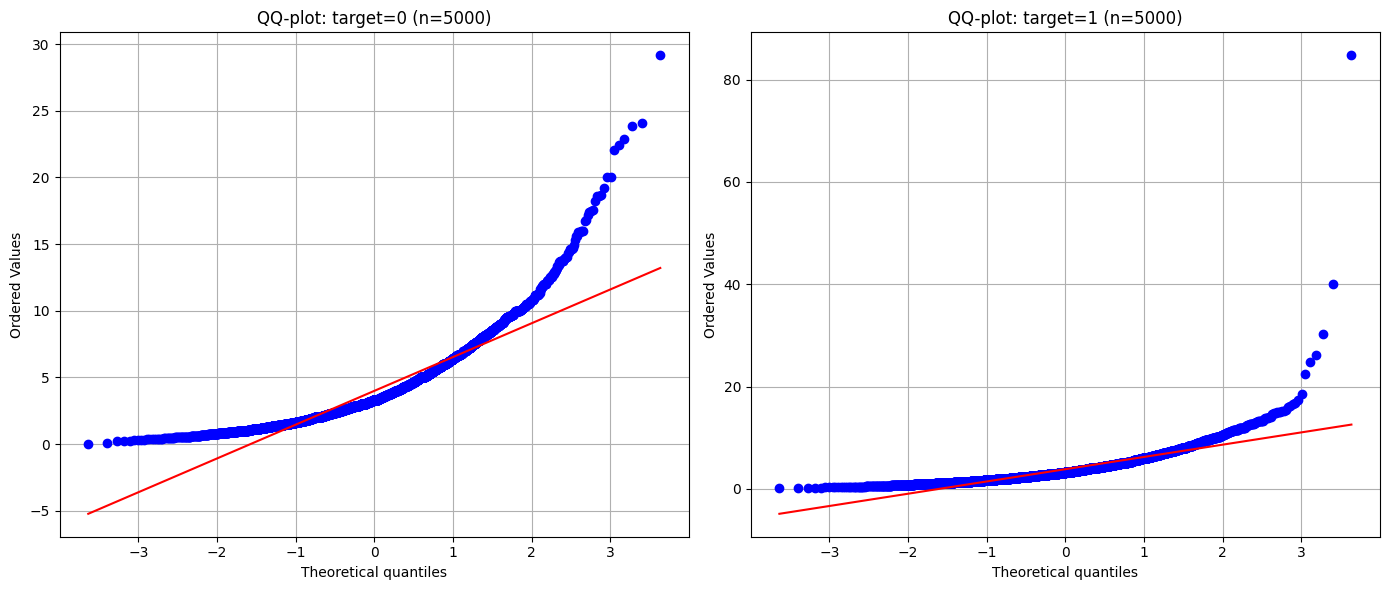

Распределение не нормальное (p-value < alpha)
p-value (0.0000000000) < alpha (0.005)
Используем непараметрический критерий (Mann-Whitney U)
U-тест Манна-Уитни:
U-statistic = 3522210255.50
p-value = 0.3187524307
Фиксированный уровень значимости alpha = 0.005
p-value (0.3187524307) >= alpha (0.005)
Не отвергаем нулевую гипотезу H0
Нет статистически значимых различий между target=0 и target=1


In [49]:
credit_to_income_target_1 = df[df["target"] == 1]["credit_to_income"]
credit_to_income_target_0 = df[df["target"] == 0]["credit_to_income"]

p_value = compare_two_groups(
    data1=credit_to_income_target_0,
    data2=credit_to_income_target_1,
    name1="target=0",
    name2="target=1",
    alpha=0.005,
)

Для проверки гипотезы о влиянии отношения кредита к доходу на дефолт был выбран U-тест Манна-Уитни по следующим причинам:

1. Тест Шапиро-Уилка показал, что распределение показателя в обеих группах не является нормальным (p < 0.005)
2. В данных присутствуют выбросы, которые могут исказить результаты t-теста
3. Размер групп сильно различается, U-тест устойчив к этому

U-тест позволяет сравнить распределения без предположения о нормальности и менее чувствителен к выбросам, что делает его более подходящим для анализа данного признака.

Ошибка 1 рода фиксируется заранее на уровне alpha = 0.005, это вероятность ложноположительного отклонения H0 (нашли эффект, когда его нет).

Ошибка 2 рода минимизируется за счет большого размера выборки и правильного выбора стат. теста

Отношение кредита к доходу не является значимым фактором, влияющим на вероятность дефолта клиента. Несмотря на наличие выбросов, распределения показателя в группах клиентов статистически неразличимы.

Для кредитного скоринга этот признак, скорее всего, не будет полезным предиктором.

## Гипотеза 2

Нулевая гипотеза (H0): Распределение стажа работы заемщиков с просрочкой и без просрочки одинаково (стаж работы не влияет на дефолт).

Альтернатива (H1): Распределение стажа работы различается

days_employed содержит отрицательные числа (дни до текущей даты) и положительные аномалии. Мы оставляем только отрицательные = реальный стаж.

In [50]:
df_clean = df[df['days_employed'] < 0].copy()

df_clean['employment_years'] = -df_clean['days_employed'] / 365.25

employment_years_target_1 = df_clean[df_clean["target"] == 1]["employment_years"]

employment_years_target_0 = df_clean[df_clean["target"] == 0]["employment_years"]

describe_group(employment_years_target_1, "Группа с target=1", target_value=1)
describe_group(employment_years_target_0, "Группа с target=0", target_value=0)

Группа с target=1 (target=1):
n = 21,834
Среднее = 4.969
Медиана = 3.368
Std = 5.064
Min = 0.005
Max = 43.995
25-й перцентиль = 1.626
75-й перцентиль = 6.518
Группа с target=0 (target=0):
n = 230,301
Среднее = 6.675
Медиана = 4.630
Std = 6.495
Min = 0.003
Max = 49.040
25-й перцентиль = 2.160
75-й перцентиль = 8.909


C:\Users\Сергей\AppData\Local\Temp\ipykernel_9688\777492551.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=["target=0", "target=1"])


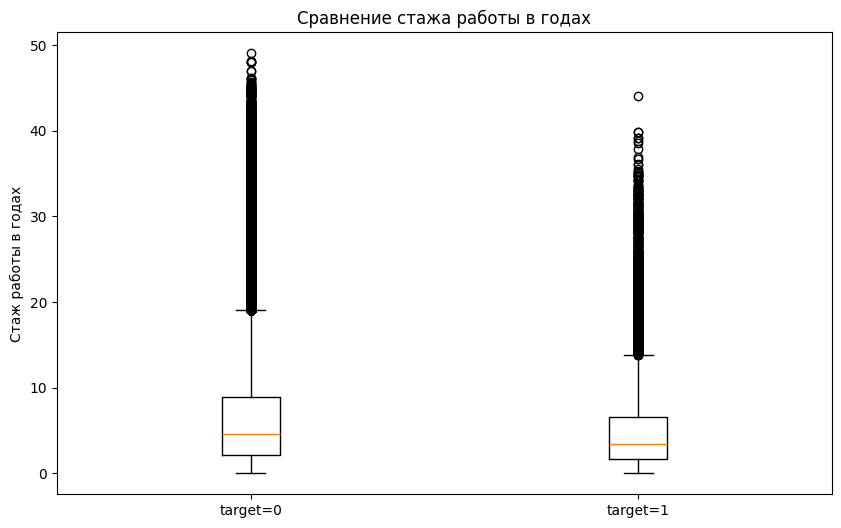

In [51]:
plt.figure(figsize=(10, 6))
data_to_plot = [employment_years_target_0, employment_years_target_1]
plt.boxplot(data_to_plot, labels=["target=0", "target=1"])
plt.title("Сравнение стажа работы в годах")
plt.ylabel("Стаж работы в годах")
plt.show()

У заемщиков с target=0 медиана стажа работы выше на 1.26 года. Проверим с помощью теста

target=0: p-value = 0.0000000000
target=1: p-value = 0.0000000000


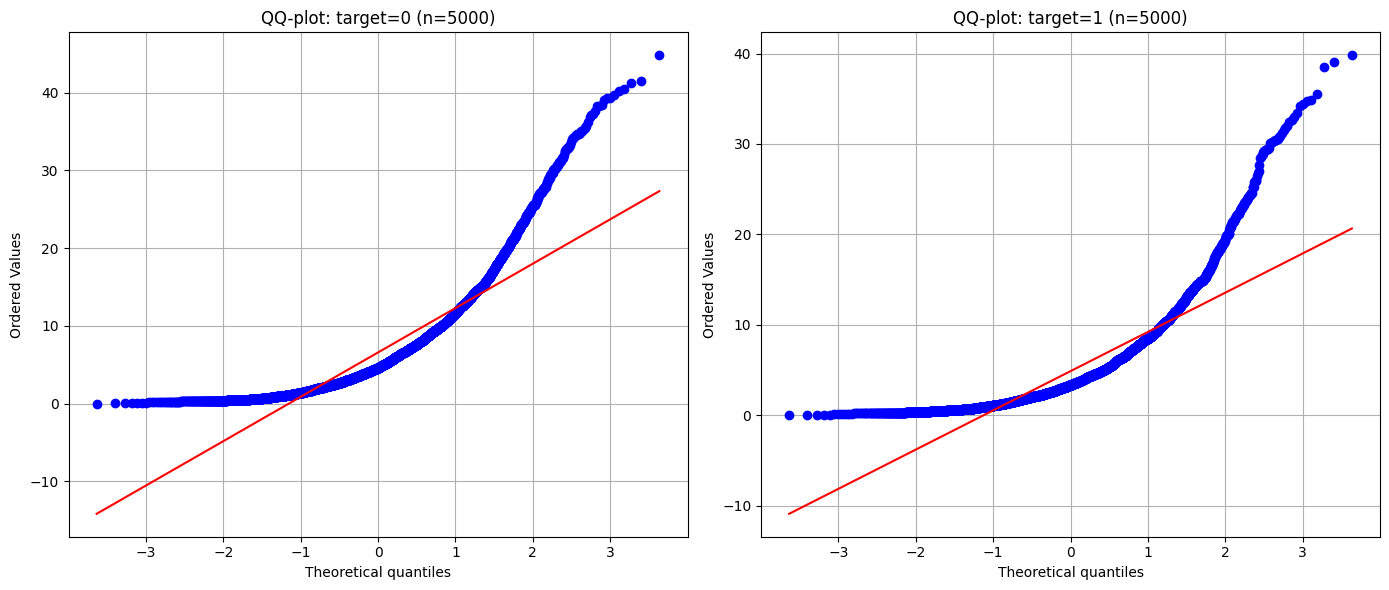

Распределение не нормальное (p-value < alpha)
p-value (0.0000000000) < alpha (0.005)
Используем непараметрический критерий (Mann-Whitney U)
U-тест Манна-Уитни:
U-statistic = 2928406791.00
p-value = 0.0000000000
Фиксированный уровень значимости alpha = 0.005
p-value (0.0000000000) < alpha (0.005)
Отвергаем нулевую гипотезу H0
target=0 и target=1 статистически значимо различаются


In [52]:
p_value = compare_two_groups(
    data1=employment_years_target_0,
    data2=employment_years_target_1,
    name1="target=0",
    name2="target=1",
    alpha=0.005,
)

Обоснование выбора теста:

1. Тест Шапиро-Уилка показал, что распределение стажа не является нормальным
2. U-тест не требует нормальности и устойчив к выбросам
3. Размеры групп сильно различаются

Отвергаем нулевую гипотезу H0. Стаж работы статистически значимо влияет на вероятность дефолта. Заемщики с большим стажем работы демонстрируют более низкий риск дефолта.

Для кредитного скоринга этот признак может быть полезным предиктором.

## Гипотеза 3

Нулевая гипотеза (H0): Семейное положение не влияет на дефолт клиента

Альтернатива (H1): Семейное положение влияет на дефолт клиента

In [53]:
family_target = pd.crosstab(df["name_family_status"], df["target"])
family_target

target,0.0,1.0
name_family_status,,
Civil marriage,26814,2961
Married,181582,14850
Separated,18150,1620
Single / not married,40987,4457
Unknown,2,0
Widow,15151,937


Посмотрим на долю дефолта в процентном соотношении внутри каждой категории

In [54]:
family_percent = (family_target[1.0] / family_target.sum(axis=1) * 100).sort_values()
family_percent.round(2)

name_family_status
Unknown                 0.00
Widow                   5.82
Married                 7.56
Separated               8.19
Single / not married    9.81
Civil marriage          9.94
dtype: float64

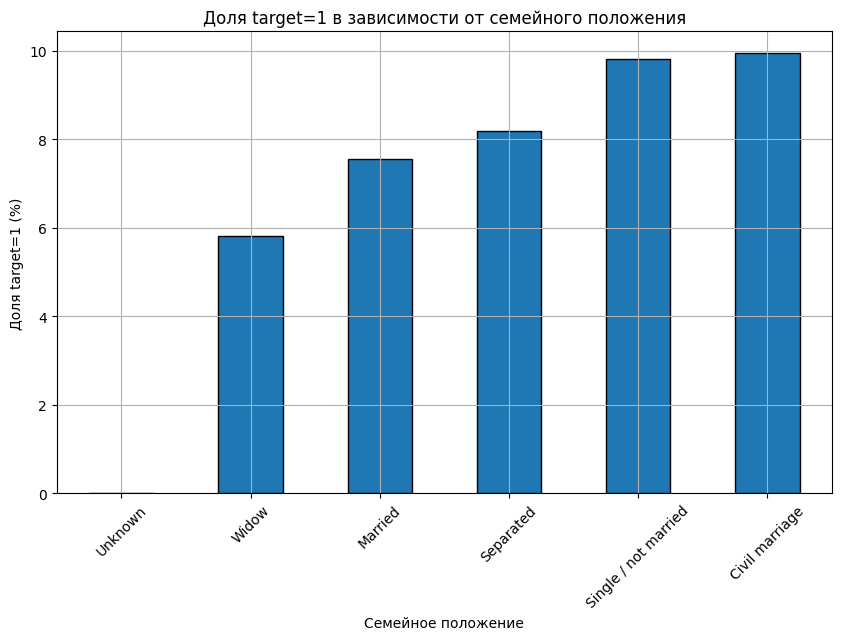

In [55]:
plt.figure(figsize=(10, 6))
family_percent.plot(kind="bar",edgecolor="black")
plt.title("Доля target=1 в зависимости от семейного положения")
plt.xlabel("Семейное положение")
plt.ylabel("Доля target=1 (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [56]:
def test_categorical(crosstab, col_name="", alpha=0.005):
    chi2, p_value, dof, expected = stats.chi2_contingency(crosstab)

    print(f"chi2 = {chi2:.2f}")
    print(f"p-value = {p_value:.10f}")
    print(f"alpha = {alpha}")

    if p_value < alpha:
        print(f"p-value ({p_value:.10f}) < {alpha}")
        print("Отвергаем H0")
        print(f"{col_name} статистически значимо влияет на target")
    else:
        print(f"p-value ({p_value:.10f}) >= {alpha}")
        print("Не отвергаем H0")
        print(f"Нет статистически значимой связи между {col_name} и target")

    return p_value

In [57]:
test_categorical(family_target, col_name="Семейное положение")

chi2 = 504.69
p-value = 0.0000000000
alpha = 0.005
p-value (0.0000000000) < 0.005
Отвергаем H0
Семейное положение статистически значимо влияет на target


np.float64(7.744841561414037e-107)

Метод проверки: хи-квадрат тест

Обоснование выбора теста:

1. Обе переменные категориальные (семейное положение и target)
2. Тест хи-квадрат позволяет проверить наличие связи между категориями

Отвергаем нулевую гипотезу H0. Семейное положение статистически значимо влияет на вероятность дефолта (по графику выше женатые пары и вдовы - самые надежные клиенты).

Для кредитного скоринга семейное положение может быть полезным предиктором.

## Гипотеза 4

Нулевая гипотеза (H0): Уровень образования не влияет на вероятность дефолта

Альтернатива (H1): Уровень образования влияет на вероятность дефолта

In [58]:
education_target = pd.crosstab(df["name_education_type"], df["target"])
education_target

target,0.0,1.0
name_education_type,,
Academic degree,161,3
Higher education,70854,4009
Incomplete higher,9405,872
Lower secondary,3399,417
Secondary / secondary special,198867,19524


In [59]:
education_percent = (education_target[1.0] / education_target.sum(axis=1) * 100).sort_values()
education_percent.round(2)

name_education_type
Academic degree                   1.83
Higher education                  5.36
Incomplete higher                 8.48
Secondary / secondary special     8.94
Lower secondary                  10.93
dtype: float64

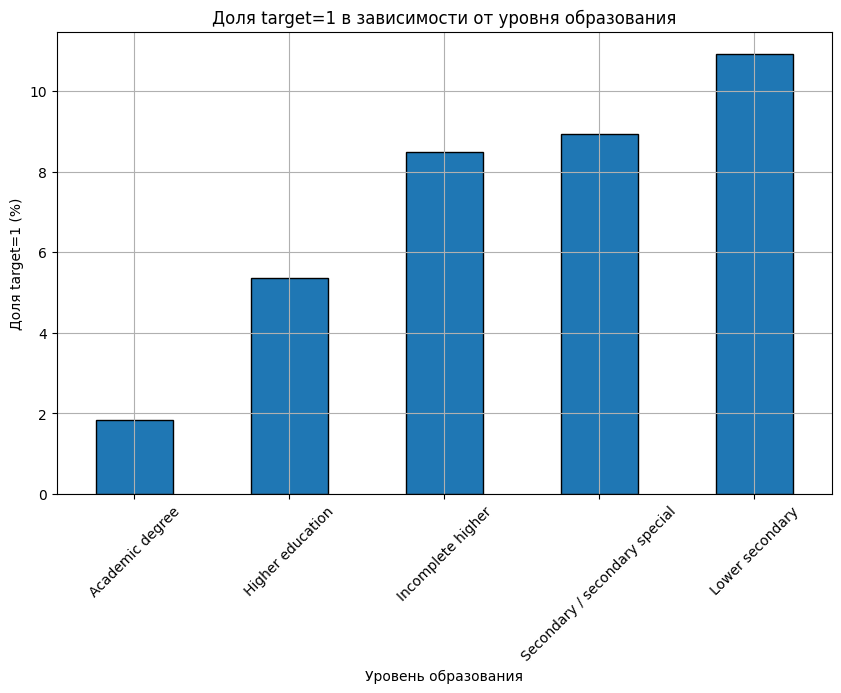

In [60]:
plt.figure(figsize=(10, 6))
education_percent.plot(kind="bar", edgecolor="black")
plt.title("Доля target=1 в зависимости от уровня образования")
plt.xlabel("Уровень образования")
plt.ylabel("Доля target=1 (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [61]:
test_categorical(education_target, col_name="Уровень образования")

chi2 = 1019.21
p-value = 0.0000000000
alpha = 0.005
p-value (0.0000000000) < 0.005
Отвергаем H0
Уровень образования статистически значимо влияет на target


np.float64(2.4476812052198174e-219)

Метод проверки: тест хи-квадрат

Обоснование:
1. Образование и target - категориальные переменные
2. тест хи-квадрат проверяет наличие статистической связи

Отвергаем нулевую гипотезу H0. Уровень образования статистически значимо влияет на вероятность просрочки.

По графику, построенному выше, можно определить надежность категорий, так как H0 отвергнута:
1. Academic degree (самые надежные)
2. Higher education
3. Incomplete higher
4. Secondary/secondary special
5. Lower secondary

Уровень образования - значимый предиктор. Заемщики с академической степенью и высшим образованием демонстрируют значительно более низкий риск дефолта по сравнению с заемщиками с образованием ниже среднего. Этот признак рекомендуется включить в модель кредитного скоринга.

## Гипотеза 5

Нулевая гипотеза (H0): Количество обращений в бюро кредитных историй за год не влияет на вероятность просрочки (средние доли просрочек во всех группах равны)

Альтернативная гипотеза (H1): Количество обращений в бюро кредитных историй влияет на просрочку (средние доли просрочек различаются хотя бы в одной группе)

C:\Users\Сергей\AppData\Local\Temp\ipykernel_9688\765846692.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  req_group_rates = df_clean.groupby('req_group')['target'].mean() * 100


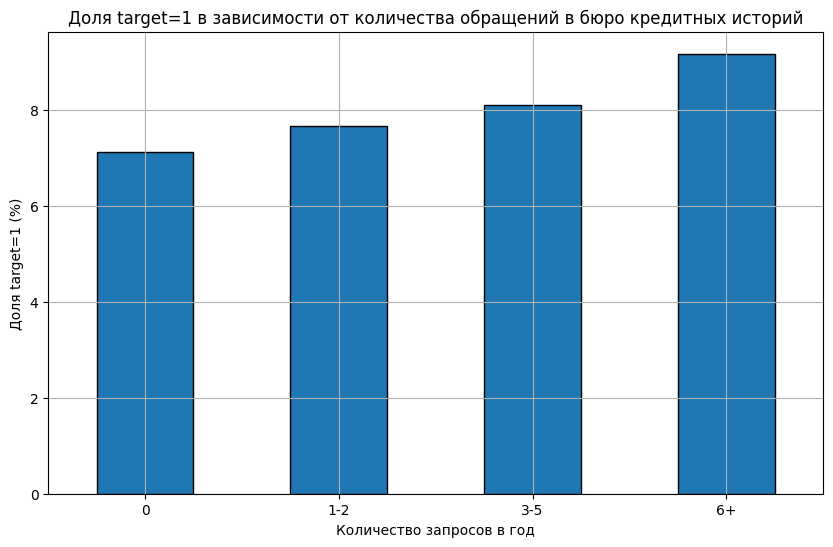

In [62]:
# Группируем количество запросов за год
df['req_group'] = pd.cut(df['amt_req_credit_bureau_year'], bins=[-1, 0, 2, 5, 100], labels=['0', '1-2', '3-5', '6+'])

# Убираем пропуски
df_clean = df.dropna(subset=['req_group', 'target'])

req_group_rates = df_clean.groupby('req_group')['target'].mean() * 100

plt.figure(figsize=(10, 6))
req_group_rates.plot(kind='bar', edgecolor='black')
plt.title("Доля target=1 в зависимости от количества обращений в бюро кредитных историй")
plt.xlabel("Количество запросов в год")
plt.ylabel("Доля target=1 (%)")
plt.xticks(rotation=0)
plt.grid(True)
plt.show()


In [63]:
groups = [df_clean[df_clean['req_group'] == g]['target'] for g in ['0', '1-2', '3-5', '6+']]
f_stat, p_value = stats.kruskal(*groups)

alpha = 0.005

print(f"F-statistic = {f_stat:.4f}")
print(f"p-value = {p_value:.10f}")
print(f"alpha = {alpha}")
    
if p_value < alpha:
    print(f"p-value ({p_value:.10f}) < alpha ({alpha})")
    print("Отвергаем нулевую гипотезу H0")
    print("Количество обращений в бюро статистически значимо влияет на дефолт клиента")
else:
    print(f"p-value ({p_value:.10f}) >= alpha ({alpha})")
    print("Не отвергаем нулевую гипотезу H0")
    print("Нет статистически значимой связи между количеством обращений и дефолтом клиента")

F-statistic = 91.7537
p-value = 0.0000000000
alpha = 0.005
p-value (0.0000000000) < alpha (0.005)
Отвергаем нулевую гипотезу H0
Количество обращений в бюро статистически значимо влияет на дефолт клиента


Стат. тест: Kruskal-Wallis (непараметрический аналог ANOVA)

Обоснование выбора теста:
1. Сравниваются более двух групп (4 группы)
2. Зависимая переменная (target) бинарная (0/1)
3. Kruskal-Wallis не требует предположения о нормальности распределения внутри групп, является непараметрическим аналогом ANOVA для порядковых/бинарных данных

Отвергаем нулевую гипотезу H0. Количество обращений в бюро кредитных историй статистически значимо влияет на вероятность дефолта клиента.

Наблюдается четкий тренд: чем чаще запрашивали кредитную историю, тем выше доля просрочек. Количество обращений в бюро кредитных историй является значимым предиктором и рекомендуется к включению в модель

## Гипотеза 6

Нулевая гипотеза (H0): Дефолт клиента не зависит от наличия недвижимости

Альтернатива (H1): У владельцев недвижимости меньше шанс дефолта

In [64]:
realty_target = pd.crosstab(df["flag_own_realty"], df["target"])
realty_target

target,0.0,1.0
flag_own_realty,,
N,86357,7842
Y,196329,16983


In [65]:
realty_percent = (realty_target[1.0] /realty_target.sum(axis=1) * 100).sort_values()
realty_percent.round(2)

flag_own_realty
Y    7.96
N    8.32
dtype: float64

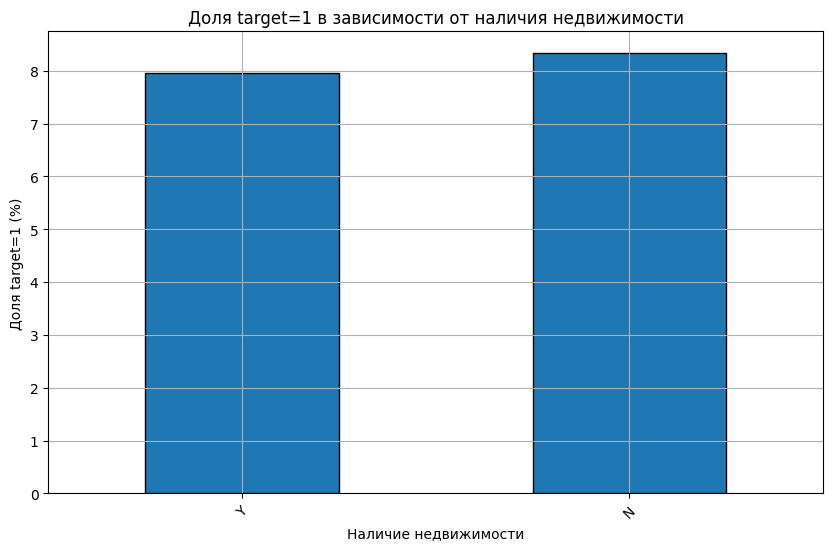

In [66]:
plt.figure(figsize=(10, 6))
realty_percent.plot(kind="bar", edgecolor="black")
plt.title("Доля target=1 в зависимости от наличия недвижимости")
plt.xlabel("Наличие недвижимости")
plt.ylabel("Доля target=1 (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [67]:
test_categorical(realty_target, col_name="Наличие недвижимости")

chi2 = 11.58
p-value = 0.0006681470
alpha = 0.005
p-value (0.0006681470) < 0.005
Отвергаем H0
Наличие недвижимости статистически значимо влияет на target


np.float64(0.0006681470317545887)

Стат. тест хи-квадрат

Обоснование:
1. Наличие недвижимости и target - категориальные переменные
2. тест хи-квадрат проверяет наличие статистической связи

Отвергаем нулевую гипотезу H0. Наличие недвижимости статистически значимо влияет на вероятность дефолта клиента.

Разница в 0.36 процентных пункта, хоть и небольшая, является статистически значимой благодаря большому размеру выборки. Для кредитного скоринга этот признак может быть полезным, но его вклад будет небольшим из-за скромной разницы в долях просрочек.